# Evaluation: Additional Value of Fundamental Data

This notebook loads only versioned results from `eval/`. It does not perform any training. The evaluation compares `market` and `full` using the same 20-day target, with daily and 20-day rebalancing. All figures include the run conditions in their titles.

## Methodology and Correctness Framework

- **Configuration:** The notebook reads the stored comparison results and records the run environment. The 20-day target horizon and rebalancing settings come from the evaluation output.
- **Time axes:** Ledger dates are converted, sorted, checked for duplicates, and used to build the reported portfolio paths. The notebook does not independently prove that every calendar day is present.
- **Features:** The feature definitions come from the stored Alpha artifacts. The notebook does not rebuild the `market` or `full` features.
- **Target:** The Alpha models predict the forward return over 20 trading days.
- **Data quality:** Missing values and non-tradable observations are handled by the data and feature pipeline before the stored evaluation results are created.
- **Splits:** Validation is used during model selection. The test split is evaluated separately and explicitly.
- **Controls:** Equal-Weight and other stored reference metrics complement the controlled `market` versus `full` comparison.
- **Models:** The comparison uses the stored XGBoost Alpha artifacts and does not perform additional model selection in the notebook.
- **Temporal design:** The data are split chronologically instead of being randomly shuffled. This is a time-ordered evaluation, not a full walk-forward study.
- **Metrics:** The report contains MSE, IC, Rank-IC, return, volatility, Sharpe ratio, drawdown, turnover, and transaction costs where available.
- **Comparison:** The conclusion is based on the same evaluation conditions, effect sizes, and both Alpha and portfolio metrics, not on one isolated best value.
- **Sensitivity:** Daily and 20-day rebalancing are compared as separate conditions.
- **Visualization:** The following cells create the result tables, equity curves, drawdowns, and PNG figures from the stored outputs.
- **Storage:** The main inputs are `eval/comparison.json` and `eval/comparison_ledgers.csv`.
- **Checks:** Missing files, invalid dates, duplicate ledger rows, and non-positive portfolio values raise an explicit error.

In [11]:
from pathlib import Path
import json
import platform
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "eval").exists():
    ROOT = ROOT.parent
RESULTS = ROOT / "eval"
COMPARISON = RESULTS / "comparison.json"
LEDGERS = RESULTS / "comparison_ledgers.csv"
if not COMPARISON.exists() or not LEDGERS.exists():
    raise FileNotFoundError(
        "Results are missing. Run pipeline/eval_comparison.py first."
    )

with COMPARISON.open(encoding="utf-8") as handle:
    comparison = json.load(handle)
ledger = pd.read_csv(LEDGERS)
ledger["date"] = pd.to_datetime(ledger["date"], utc=True)
ledger["portfolio_value"] = pd.to_numeric(ledger["portfolio_value"], errors="raise")
ledger = ledger.sort_values(["split", "alpha", "book", "rebalance_every", "date"])

assert not ledger.duplicated(
    ["split", "alpha", "book", "rebalance_every", "date"]
).any(), "Duplicate ledger rows found."
assert ledger["portfolio_value"].gt(0).all(), "Portfolio values must be positive."
assert ledger["date"].notna().all(), "Ledger contains invalid dates."

print({"python": sys.version.split()[0], "platform": platform.platform()})
print(comparison.get("alpha_horizon_days"), "trading-day Alpha horizon")
print(f"{len(ledger):,} ledger rows loaded")

{'python': '3.13.14', 'platform': 'Linux-7.1.11-arch1-1-x86_64-with-glibc2.44'}
20 trading-day Alpha horizon
368 ledger rows loaded


In [12]:
alpha_metrics = []
for split, models in comparison.get("alpha_quality", {}).items():
    for alpha, metrics in models.items():
        row = {"split": split, "alpha": alpha, **metrics}
        alpha_metrics.append(row)
alpha_table = pd.DataFrame(alpha_metrics)
alpha_table

,split,alpha,mse,ic,n_samples,score_autocorr_1d,rank_ic_mean,rank_ic_median,rank_ic_std,rank_ic_n_days,pearson_ic_mean,pearson_ic_median,pearson_ic_n_days,feature_set
0,test,market,0.021336,-0.015834,1079.0,0.926667,0.036146,0.073684,0.309798,54.0,0.023599,0.046491,54.0,market_only
1,test,full,0.019879,-0.061240,1079.0,0.961015,-0.059649,-0.100752,0.308523,54.0,-0.036112,-0.027870,54.0,with_fundamentals


In [13]:
portfolio_table = pd.DataFrame(
    [
        {
            "split": run["split"],
            "alpha": run["alpha"],
            "book": run["book"],
            "hold": run["hold"],
            "rebalance_every": run["rebalance_every"],
            **run["metrics"],
        }
        for run in comparison.get("runs", [])
    ]
)
portfolio_table.sort_values(["split", "alpha", "rebalance_every", "book"])

,split,alpha,book,hold,rebalance_every,mean_reward,n_steps,action_share_sell,action_share_hold,action_share_buy,mean_log_return,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,mean_turnover,total_transaction_cost,equal_weight_mean_log_return,allow_short
2,test,full,long_only,daily,1.0,0.001645,91,0.312088,0.467582,0.220330,0.001645,0.161522,0.513827,0.322284,1.446137,-0.213939,0.194505,20084.767545,0.002594,0.0
3,test,full,long_only,20d,20.0,0.001953,91,0.312088,0.467582,0.220330,0.001953,0.194504,0.635876,0.315542,1.715681,-0.184453,0.034827,3556.275436,0.002594,0.0
0,test,market,long_only,daily,1.0,0.001779,91,0.261538,0.607692,0.130769,0.001779,0.175753,0.565745,0.347437,1.463017,-0.217633,0.167256,16587.201344,0.002594,0.0
1,test,market,long_only,20d,20.0,0.002344,91,0.261538,0.607692,0.130769,0.002344,0.237798,0.805381,0.354788,1.842237,-0.222033,0.024310,2524.697295,0.002594,0.0


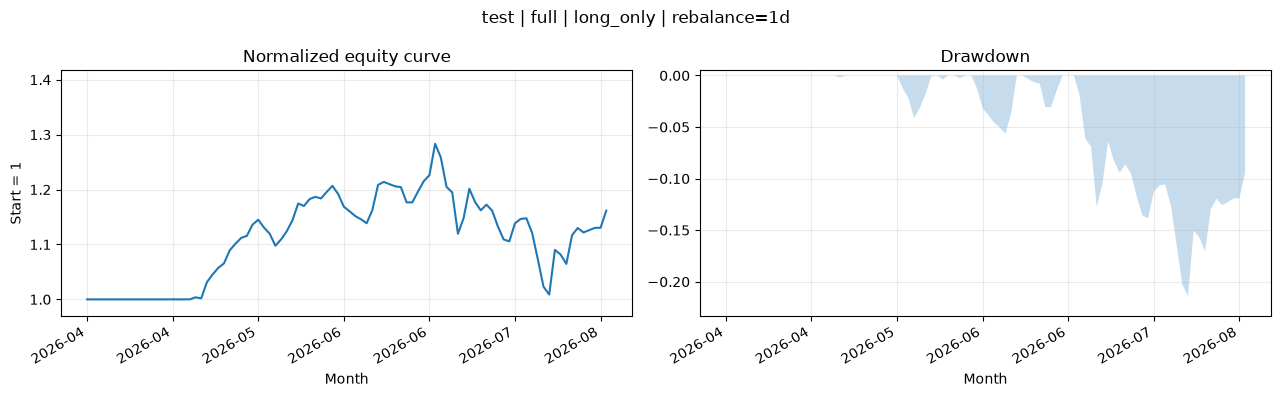

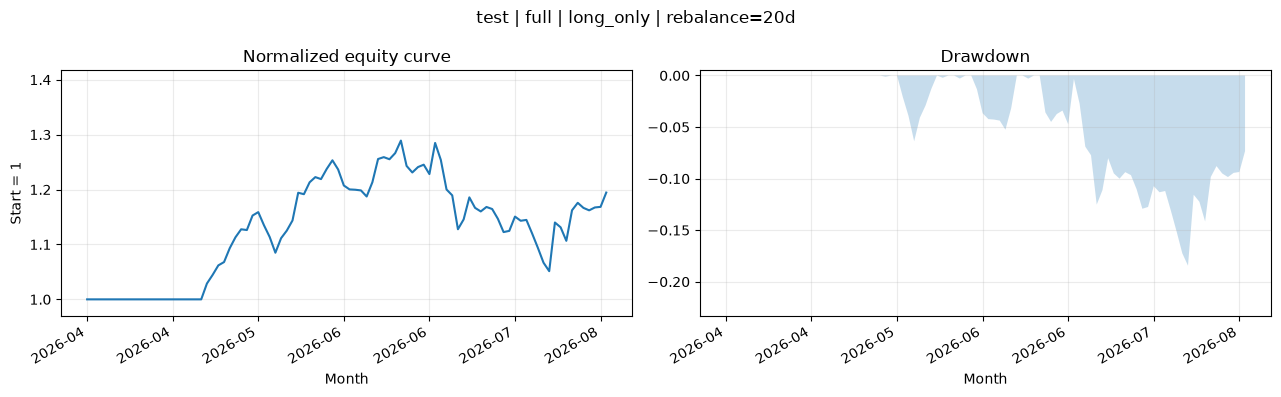

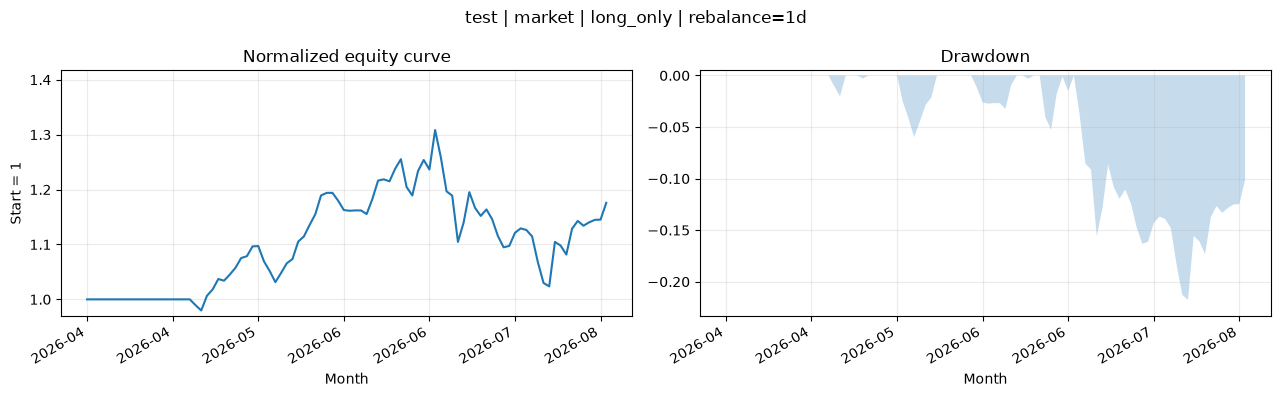

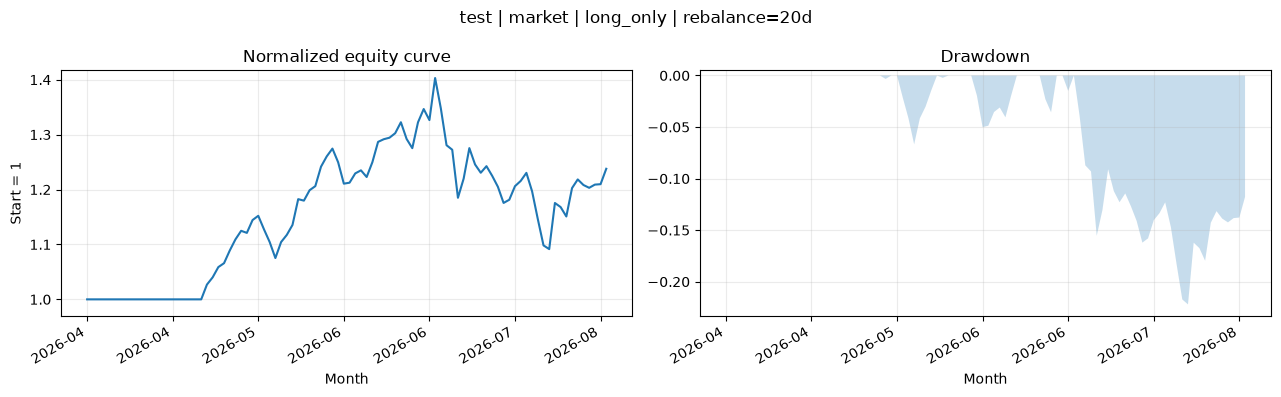

In [14]:
plot_frame = ledger.copy()
plot_frame["equity"] = plot_frame.groupby(
    ["split", "alpha", "book", "rebalance_every"]
)["portfolio_value"].transform(lambda values: values / values.iloc[0])
plot_frame["drawdown"] = plot_frame["equity"] / plot_frame.groupby(
    ["split", "alpha", "book", "rebalance_every"]
)["equity"].cummax() - 1.0

equity_min = plot_frame["equity"].min()
equity_max = plot_frame["equity"].max()
drawdown_min = plot_frame["drawdown"].min()
for (split, alpha, book, every), group in plot_frame.groupby(
    ["split", "alpha", "book", "rebalance_every"], sort=True
):
    label = f"{split} | {alpha} | {book} | rebalance={int(every)}d"
    x = list(range(len(group)))
    tick_positions = list(range(0, len(group), max(len(group) // 6, 1)))
    tick_labels = group.iloc[tick_positions]["date"].dt.strftime("%Y-%m")
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
    axes[0].plot(x, group["equity"])
    axes[0].set_title("Normalized equity curve")
    axes[0].set_ylabel("Start = 1")
    axes[0].set_ylim(equity_min * 0.99, equity_max * 1.01)
    axes[1].fill_between(x, group["drawdown"], 0.0, alpha=0.25)
    axes[1].set_title("Drawdown")
    axes[1].set_ylim(drawdown_min * 1.05, 0.005)
    for axis in axes:
        axis.set_xlabel("Month")
        axis.set_xticks(tick_positions, tick_labels, rotation=30, ha="right")
        axis.grid(alpha=0.25)
    fig.suptitle(label)
    plt.tight_layout()
    plt.show()

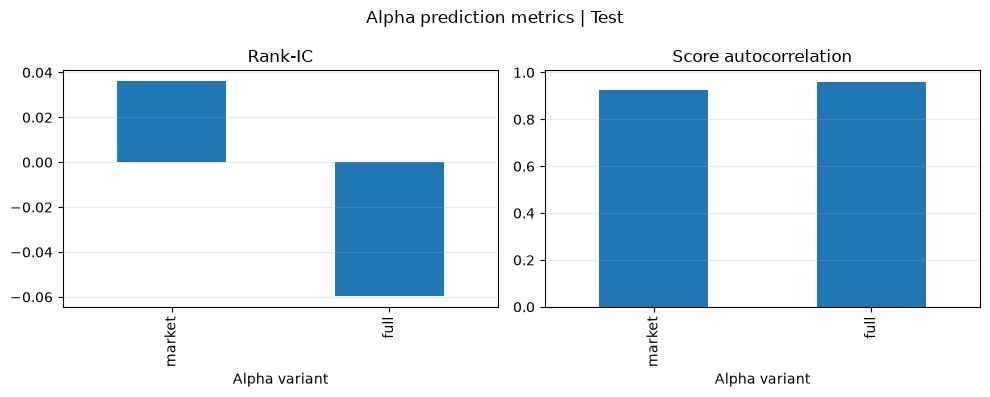

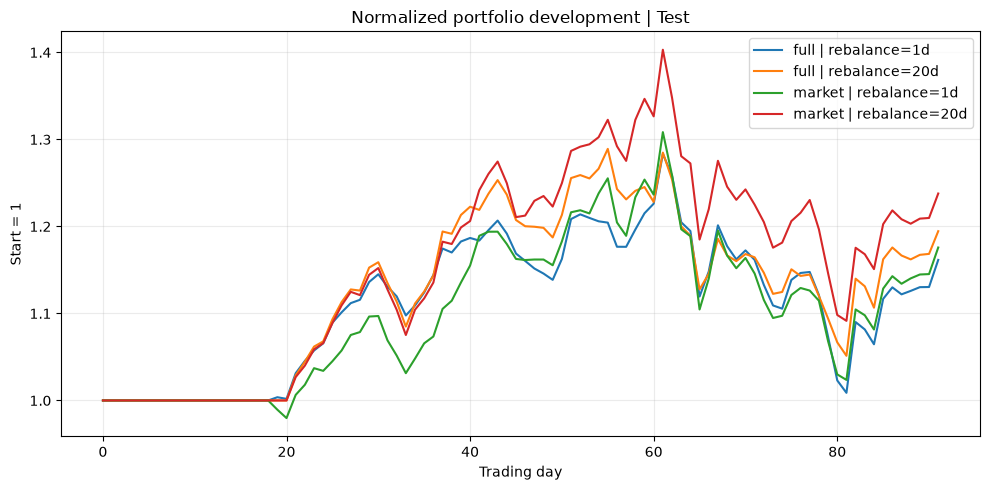

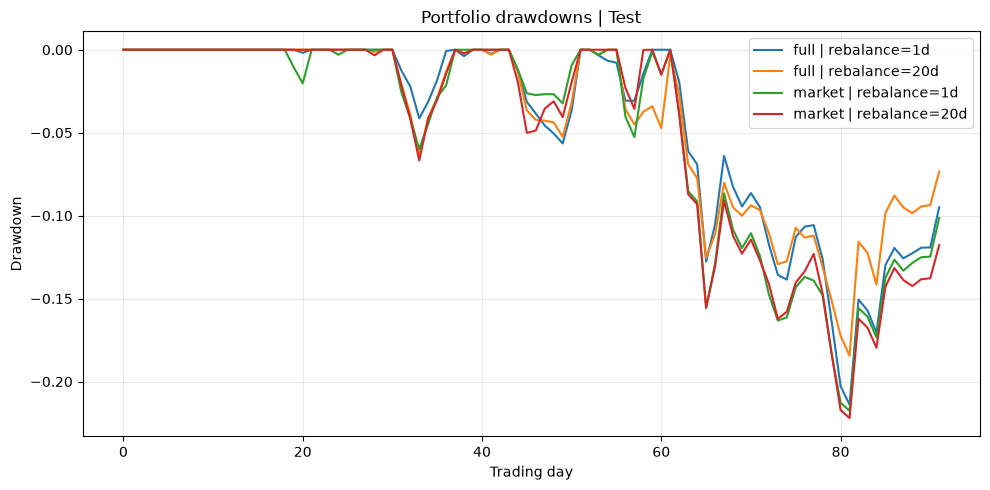

In [16]:
IMAGE_DIR = ROOT / "images"
IMAGE_DIR.mkdir(exist_ok=True)

alpha_plot = alpha_table[alpha_table["split"] == "test"].set_index("alpha")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
alpha_plot["rank_ic_mean"].plot.bar(ax=axes[0], title="Rank-IC")
alpha_plot["score_autocorr_1d"].plot.bar(ax=axes[1], title="Score autocorrelation")
for axis in axes:
    axis.grid(axis="y", alpha=0.25)
    axis.set_xlabel("Alpha variant")
fig.suptitle("Alpha prediction metrics | Test")
fig.tight_layout()
fig.savefig(IMAGE_DIR / "alpha_quality_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

plot_frame = ledger[ledger["split"] == "test"].copy()
plot_frame["equity"] = plot_frame.groupby(
    ["alpha", "book", "rebalance_every"]
)["portfolio_value"].transform(lambda values: values / values.iloc[0])
plot_frame["drawdown"] = plot_frame["equity"] / plot_frame.groupby(
    ["alpha", "book", "rebalance_every"]
)["equity"].cummax() - 1.0

fig, axis = plt.subplots(figsize=(10, 5))
for (alpha, book, every), group in plot_frame.groupby(
    ["alpha", "book", "rebalance_every"], sort=True
):
    axis.plot(
        range(len(group)),
        group["equity"],
        label=f"{alpha} | rebalance={int(every)}d",
    )
axis.set_title("Normalized portfolio development | Test")
axis.set_xlabel("Trading day")
axis.set_ylabel("Start = 1")
axis.grid(alpha=0.25)
axis.legend()
fig.tight_layout()
fig.savefig(IMAGE_DIR / "portfolio_equity_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axis = plt.subplots(figsize=(10, 5))
for (alpha, book, every), group in plot_frame.groupby(
    ["alpha", "book", "rebalance_every"], sort=True
):
    axis.plot(
        range(len(group)),
        group["drawdown"],
        label=f"{alpha} | rebalance={int(every)}d",
    )
axis.set_title("Portfolio drawdowns | Test")
axis.set_xlabel("Trading day")
axis.set_ylabel("Drawdown")
axis.grid(alpha=0.25)
axis.legend()
fig.tight_layout()
fig.savefig(IMAGE_DIR / "portfolio_drawdown_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

# print(f"PNG files saved to: {IMAGE_DIR}")